In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the COVID-19 dataset
df = pd.read_csv("states.csv")

# Display the first five records
print("COVID-19 Dataset:")
display(df.head())

# Display dataset dimensions
print("Dataset Shape:", df.shape)

COVID-19 Dataset:


,Date,State,Confirmed,Recovered,Deceased,Other,Tested
0,2020-01-30,India,1,0,0,0,0
1,2020-01-30,Kerala,1,0,0,0,0
2,2020-02-02,India,2,0,0,0,0
3,2020-02-02,Kerala,2,0,0,0,0
4,2020-02-03,India,3,0,0,0,0


Dataset Shape: (45614, 7)


In [ ]:
import pandas as pd

# Load the COVID-19 dataset
df = pd.read_csv("states.csv")

print("First 5 Records:")
display(df.head())

# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display column names
print("\nDataset Columns:")
print(df.columns.tolist())

# Display information about the dataset
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

First 5 Records:


,Date,State,Confirmed,Recovered,Deceased,Other,Tested
0,2020-01-30,India,1,0,0,0,0
1,2020-01-30,Kerala,1,0,0,0,0
2,2020-02-02,India,2,0,0,0,0
3,2020-02-02,Kerala,2,0,0,0,0
4,2020-02-03,India,3,0,0,0,0


Dataset Shape: (45614, 7)

Dataset Columns:
['Date', 'State', 'Confirmed', 'Recovered', 'Deceased', 'Other', 'Tested']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45614 entries, 0 to 45613
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       45614 non-null  object
 1   State      45614 non-null  object
 2   Confirmed  45614 non-null  int64 
 3   Recovered  45614 non-null  int64 
 4   Deceased   45614 non-null  int64 
 5   Other      45614 non-null  int64 
 6   Tested     45614 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 2.4+ MB

Statistical Summary:


,Confirmed,Recovered,Deceased,Other,Tested
count,4.561400e+04,4.561400e+04,45614.000000,45614.000000,4.561400e+04
mean,1.578787e+06,1.537735e+06,19553.455167,233.441597,2.657770e+07
std,5.566403e+06,5.462961e+06,69161.738072,1225.324428,1.064839e+08
min,0.000000e+00,0.000000e+00,0.000000,-1.000000,0.000000e+00
25%,2.971425e+04,2.893525e+04,296.000000,0.000000,3.477500e+03
50%,2.455760e+05,2.382430e+05,3198.000000,0.000000,1.252672e+06
75%,1.030570e+06,9.939538e+05,10786.000000,0.000000,1.934104e+07
max,4.499673e+07,4.446333e+07,531926.000000,13196.000000,9.344781e+08


In [ ]:
import pandas as pd

# Load the COVID-19 dataset
df = pd.read_csv("states.csv")

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:")
print(df.duplicated().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check state categories
print("\nUnique States:")
print(df["State"].unique())

# Check India and State Unassigned records
print("\nSpecial State Records:")
print(df["State"].value_counts().loc[
    ["India", "State Unassigned"]
])

Missing Values:
Date         0
State        0
Confirmed    0
Recovered    0
Deceased     0
Other        0
Tested       0
dtype: int64

Duplicate Records:
0

Data Types:
Date         object
State        object
Confirmed     int64
Recovered     int64
Deceased      int64
Other         int64
Tested        int64
dtype: object

Unique States:
['India' 'Kerala' 'Delhi' 'Telangana' 'Rajasthan' 'Haryana'
 'Uttar Pradesh' 'Ladakh' 'Tamil Nadu' 'Jammu and Kashmir' 'Karnataka'
 'Maharashtra' 'Punjab' 'Andhra Pradesh' 'Himachal Pradesh' 'Uttarakhand'
 'Odisha' 'Puducherry' 'West Bengal' 'Chandigarh' 'Chhattisgarh' 'Gujarat'
 'Madhya Pradesh' 'Bihar' 'Manipur' 'Goa' 'Mizoram'
 'Andaman and Nicobar Islands' 'Assam' 'Jharkhand' 'Arunachal Pradesh'
 'Nagaland' 'Tripura' 'Dadra and Nagar Haveli and Daman and Diu'
 'Meghalaya' 'Sikkim' 'State Unassigned' 'Lakshadweep']

Special State Records:
State
India               1260
State Unassigned      61
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Load the COVID-19 dataset
df = pd.read_csv("states.csv")

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

print("Date Data Type:")
print(df["Date"].dtype)

# Create a separate dataset for state-wise analysis
state_df = df[
    ~df["State"].isin(["India", "State Unassigned"])
].copy()

print("\nOriginal Dataset Shape:")
print(df.shape)

print("\nState-wise Dataset Shape:")
print(state_df.shape)

print("\nState-wise Data:")
display(state_df.head())

Date Data Type:
datetime64[ns]

Original Dataset Shape:
(45614, 7)

State-wise Dataset Shape:
(44293, 7)

State-wise Data:


,Date,State,Confirmed,Recovered,Deceased,Other,Tested
1,2020-01-30,Kerala,1,0,0,0,0
3,2020-02-02,Kerala,2,0,0,0,0
5,2020-02-03,Kerala,3,0,0,0,0
7,2020-02-14,Kerala,3,3,0,0,0
8,2020-03-02,Delhi,1,0,0,0,0


In [ ]:
# Sort state-wise data by State and Date
state_df = state_df.sort_values(["State", "Date"])

# Get the latest available record for each state
latest_cases = state_df.groupby("State").tail(1)

# Get the latest non-zero testing value for each state
latest_tested = (
    state_df[state_df["Tested"] > 0]
    .groupby("State")
    .tail(1)
)

# Combine the latest case information with the latest valid testing value
state_analysis = latest_cases[
    ["State", "Confirmed", "Recovered", "Deceased"]
].copy()

state_analysis = state_analysis.merge(
    latest_tested[["State", "Tested"]],
    on="State",
    how="left"
)

# Set State as index
state_analysis = state_analysis.set_index("State")

# Sort by confirmed cases
state_analysis = state_analysis.sort_values(
    by="Confirmed",
    ascending=False
)

print("State-wise COVID-19 Analysis:")
display(state_analysis)

State-wise COVID-19 Analysis:


,Confirmed,Recovered,Deceased,Tested
State,,,,
Maharashtra,8170491,8021807,148557,84698385
Kerala,6907181,6834229,71947,49030651
Karnataka,4088741,4048369,40357,69414797
Tamil Nadu,3610641,3572554,38081,69765914
Andhra Pradesh,2340676,2325943,14733,33535691
Uttar Pradesh,2145416,2121650,23709,83473764
West Bengal,2126088,2104350,21555,26679487
Delhi,2040861,2014186,26666,39999533
Odisha,1348395,1339122,9215,33843618


In [ ]:
# Top 10 States by Confirmed Cases

top_10_confirmed = state_analysis.head(10)

print("Top 10 States by Confirmed Cases:")
display(top_10_confirmed[["Confirmed"]])

Top 10 States by Confirmed Cases:


,Confirmed
State,
Maharashtra,8170491
Kerala,6907181
Karnataka,4088741
Tamil Nadu,3610641
Andhra Pradesh,2340676
Uttar Pradesh,2145416
West Bengal,2126088
Delhi,2040861
Odisha,1348395


In [ ]:
# Monthly Time-Series Analysis

# Create a copy of state-wise data
monthly_df = state_df.copy()

# Extract year and month
monthly_df["YearMonth"] = monthly_df["Date"].dt.to_period("M")

# Get the latest record of each state for every month
monthly_latest = (
    monthly_df
    .sort_values(["State", "Date"])
    .groupby(["State", "YearMonth"])
    .tail(1)
)

# Combine the latest state records for each month
monthly_time_series = (
    monthly_latest
    .groupby("YearMonth")[["Confirmed", "Recovered", "Deceased", "Tested"]]
    .sum()
)

print("Monthly COVID-19 Time-Series Data:")
display(monthly_time_series.head())

Monthly COVID-19 Time-Series Data:


,Confirmed,Recovered,Deceased,Tested
YearMonth,,,,
2020-01,1,0,0,0
2020-02,3,3,0,0
2020-03,1635,160,47,0
2020-04,34867,9059,1154,1003252
2020-05,185157,91862,5405,4251425


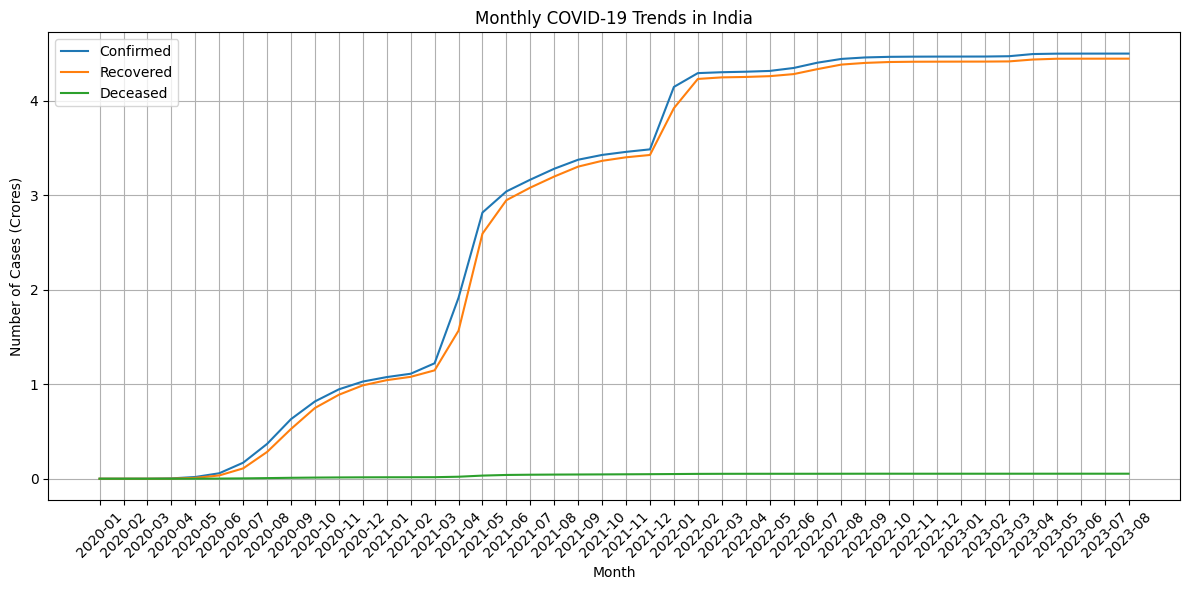

In [ ]:
# Monthly COVID-19 Trend - Line Chart in Crores

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_time_series.index.astype(str),
    monthly_time_series["Confirmed"] / 1e7,
    label="Confirmed"
)

plt.plot(
    monthly_time_series.index.astype(str),
    monthly_time_series["Recovered"] / 1e7,
    label="Recovered"
)

plt.plot(
    monthly_time_series.index.astype(str),
    monthly_time_series["Deceased"] / 1e7,
    label="Deceased"
)

plt.xlabel("Month")
plt.ylabel("Number of Cases (Crores)")
plt.title("Monthly COVID-19 Trends in India")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

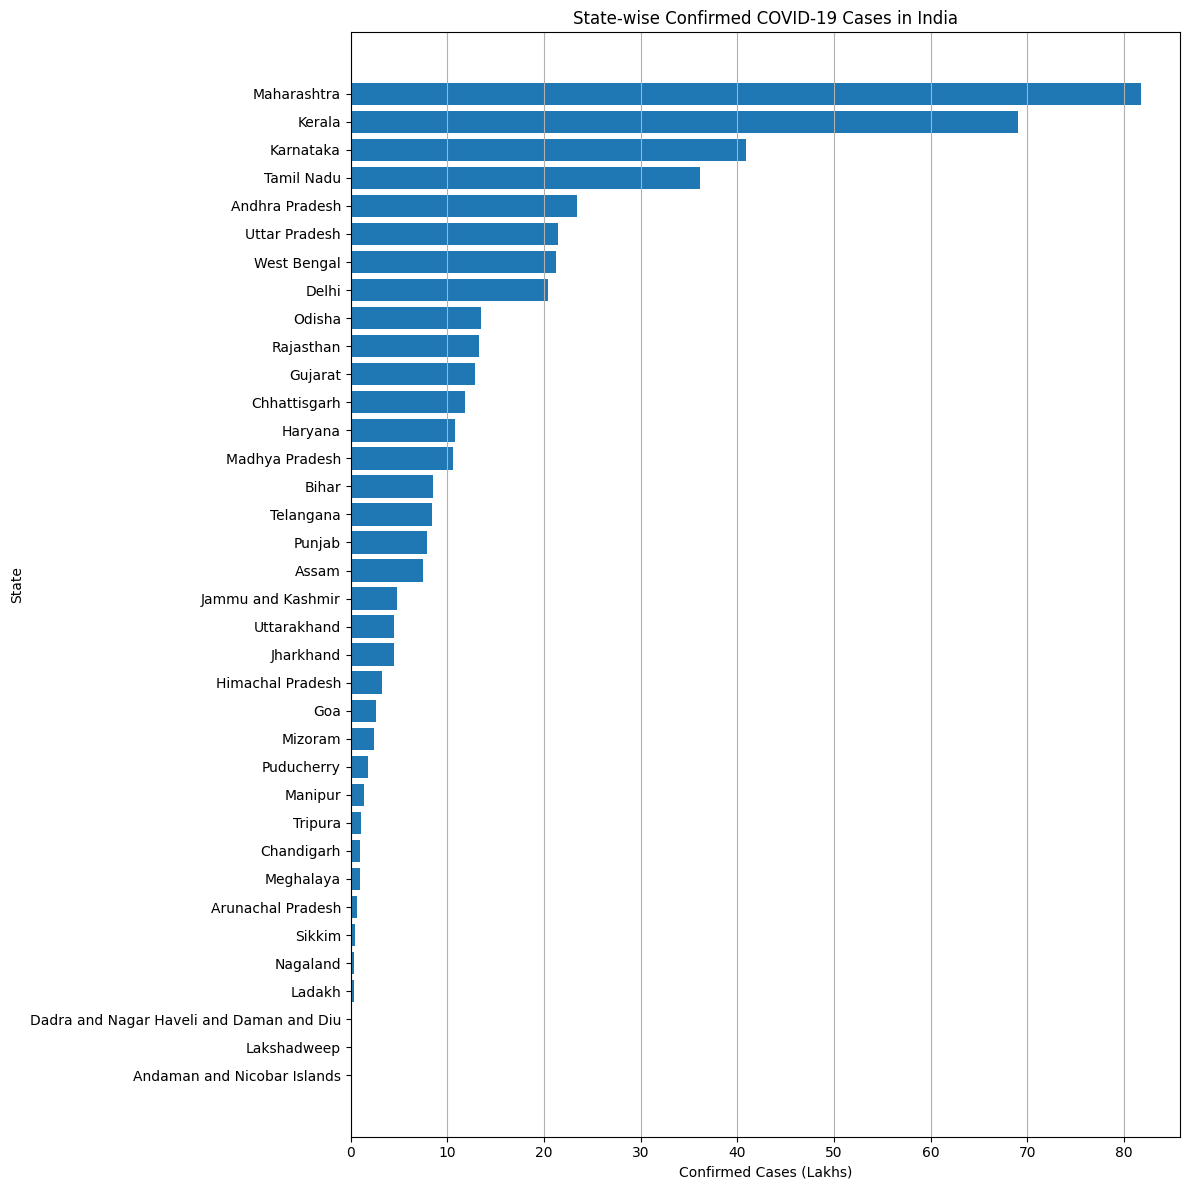

In [ ]:
# Bar Chart - All States by Confirmed Cases

import matplotlib.pyplot as plt

# Sort all states by confirmed cases
all_states = state_analysis.sort_values(
    by="Confirmed",
    ascending=True
)

plt.figure(figsize=(12, 12))

plt.barh(
    all_states.index,
    all_states["Confirmed"] / 1e5
)

plt.xlabel("Confirmed Cases (Lakhs)")
plt.ylabel("State")
plt.title("State-wise Confirmed COVID-19 Cases in India")

plt.grid(axis="x")
plt.tight_layout()

plt.show()

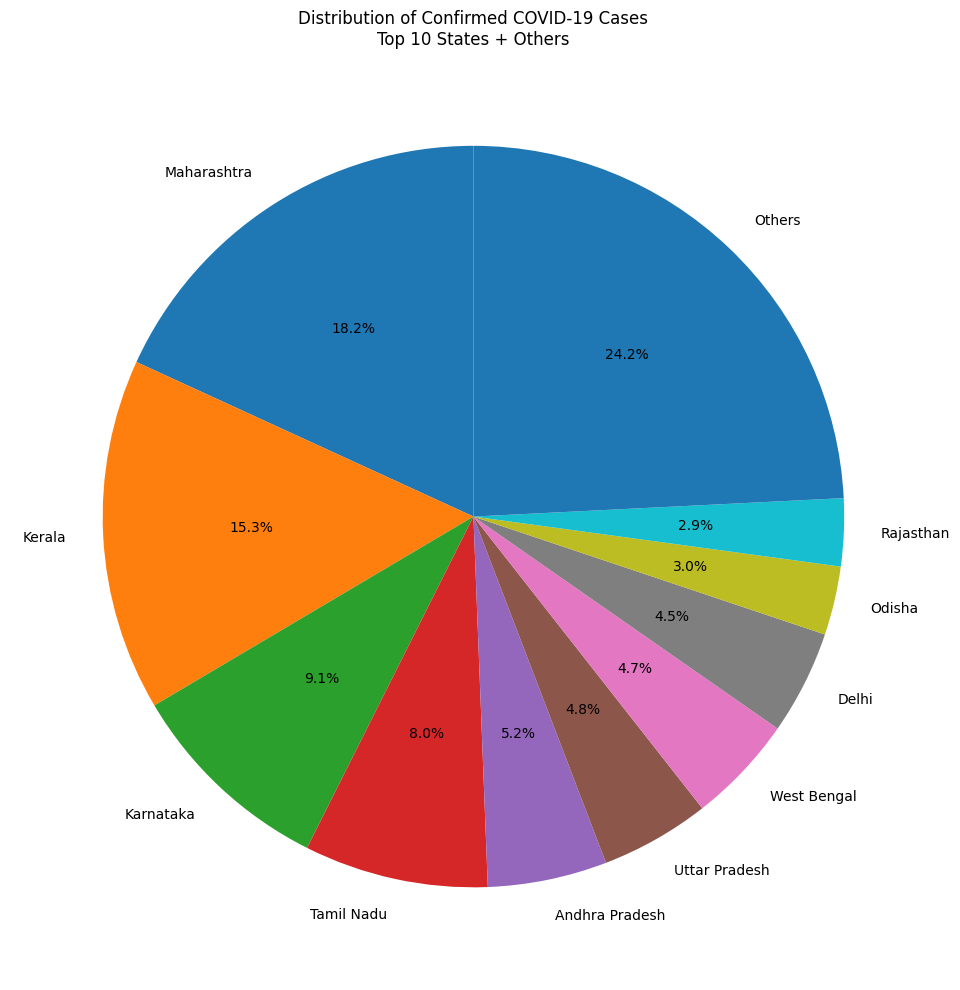

In [ ]:
# Pie Chart - Top 10 States + Others

import matplotlib.pyplot as plt

# Get confirmed cases for all states
confirmed_cases = state_analysis["Confirmed"].sort_values(
    ascending=False
)

# Select top 10 states
top_10 = confirmed_cases.head(10)

# Combine remaining states into "Others"
others = confirmed_cases.iloc[10:].sum()

# Create pie chart data
pie_data = top_10.copy()
pie_data["Others"] = others

plt.figure(figsize=(10, 10))

plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Distribution of Confirmed COVID-19 Cases\n"
    "Top 10 States + Others"
)

plt.tight_layout()
plt.show()

In [ ]:
# COVID-19 DATA ANALYSIS DASHBOARD

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Dashboard libraries loaded successfully.")

Dashboard libraries loaded successfully.


In [ ]:
# Prepare Dashboard Data

# State-wise totals from the latest available state records
total_confirmed = state_analysis["Confirmed"].sum()
total_recovered = state_analysis["Recovered"].sum()
total_deceased = state_analysis["Deceased"].sum()
total_states = state_analysis.shape[0]

# Data for bar chart
bar_data = state_analysis.sort_values(
    by="Confirmed",
    ascending=True
)

# Data for pie chart
confirmed_sorted = state_analysis["Confirmed"].sort_values(
    ascending=False
)

top_10 = confirmed_sorted.head(10)
others = confirmed_sorted.iloc[10:].sum()

pie_data = top_10.copy()
pie_data["Others"] = others

print("Dashboard data prepared successfully.")

Dashboard data prepared successfully.


In [ ]:
# COVID-19 Dashboard with Line, Bar and Pie Charts

fig = make_subplots(
    rows=4,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy", "colspan": 2}, None],
        [{"type": "xy"}, {"type": "domain"}]
    ],
    subplot_titles=(
        "Total Confirmed Cases",
        "Total Recovered Cases",
        "Total Deceased Cases",
        "States / Regions Analyzed",
        "Monthly COVID-19 Trend",
        "State-wise Confirmed Cases",
        "Confirmed Cases Distribution"
    ),
    vertical_spacing=0.08,
    horizontal_spacing=0.08
)

# -----------------------------
# KPI 1 - Confirmed
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_confirmed,
        number={"valueformat": ",", "font": {"size": 30}}
    ),
    row=1,
    col=1
)

# -----------------------------
# KPI 2 - Recovered
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_recovered,
        number={"valueformat": ",", "font": {"size": 30}}
    ),
    row=1,
    col=2
)

# -----------------------------
# KPI 3 - Deceased
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_deceased,
        number={"valueformat": ",", "font": {"size": 30}}
    ),
    row=2,
    col=1
)

# -----------------------------
# KPI 4 - States
# -----------------------------

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_states,
        number={"valueformat": ",", "font": {"size": 30}}
    ),
    row=2,
    col=2
)

# -----------------------------
# LINE CHART
# -----------------------------

fig.add_trace(
    go.Scatter(
        x=monthly_time_series.index.astype(str),
        y=monthly_time_series["Confirmed"],
        mode="lines",
        name="Confirmed"
    ),
    row=3,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly_time_series.index.astype(str),
        y=monthly_time_series["Recovered"],
        mode="lines",
        name="Recovered"
    ),
    row=3,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly_time_series.index.astype(str),
        y=monthly_time_series["Deceased"],
        mode="lines",
        name="Deceased"
    ),
    row=3,
    col=1
)

# -----------------------------
# BAR CHART - ALL STATES
# -----------------------------

all_states = state_analysis.sort_values(
    by="Confirmed",
    ascending=True
)

fig.add_trace(
    go.Bar(
        x=all_states["Confirmed"],
        y=all_states.index,
        orientation="h",
        name="Confirmed by State"
    ),
    row=4,
    col=1
)

# -----------------------------
# PIE CHART
# -----------------------------

fig.add_trace(
    go.Pie(
        labels=pie_data.index,
        values=pie_data.values,
        hole=0.3,
        textinfo="percent"
    ),
    row=4,
    col=2
)

# -----------------------------
# AXIS LABELS
# -----------------------------

fig.update_xaxes(
    title_text="Month",
    row=3,
    col=1
)

fig.update_yaxes(
    title_text="Number of Cases",
    row=3,
    col=1
)

fig.update_xaxes(
    title_text="Confirmed Cases",
    row=4,
    col=1
)

fig.update_yaxes(
    title_text="State",
    row=4,
    col=1
)

# -----------------------------
# DASHBOARD LAYOUT
# -----------------------------

fig.update_layout(
    title={
        "text": "COVID-19 DATA ANALYSIS DASHBOARD",
        "x": 0.5,
        "xanchor": "center"
    },
    height=1400,
    showlegend=True
)

fig.show()